# Фаза 1.1 — разведочный анализ: молекулы и запахи

Датасет: `curated_GS_LF_merged_4983` (OpenPOM, лицензия MIT, запинен на коммит `8c345c1`).
4983 молекулы, каждой эксперты-парфюмеры приписали набор запахов из словаря в 138 слов.

Задача Фазы 1 — предсказывать этот набор по структуре молекулы. Прежде чем что-то
предсказывать, нужно понять, что именно предсказывается. Блокнот отвечает на пять вопросов:

1. Как устроена одна строка данных?
2. Сколько запахов у молекулы и насколько разрежена задача?
3. Насколько неравномерны частоты дескрипторов и что это делает с **измерением** качества?
4. Какие запахи ходят парами — и есть ли между ними структура?
5. Как выглядят сами молекулы, все ли они читаются, и нет ли странностей в разметке?

Выводы в конце — прямые входные данные для шагов 1.3 (сплит) и 1.4 (метрики).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sillage.data.loaders import load_curated_openpom
from sillage.data.schemas import DESCRIPTORS_COLUMN, OPENPOM_DESCRIPTORS, SMILES_COLUMN

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})

df = load_curated_openpom()
labels = list(OPENPOM_DESCRIPTORS)
Y = df[labels].to_numpy(dtype=bool)

print(f"молекул:      {len(df)}")
print(f"дескрипторов: {len(labels)}")
print(f"матрица меток: {Y.shape}, положительных {Y.sum()} ({Y.mean() * 100:.1f}% ячеек)")

молекул:      4983
дескрипторов: 138
матрица меток: (4983, 138), положительных 24312 (3.5% ячеек)


## 1. Как устроена одна строка

Две содержательные колонки: `nonStereoSMILES` — структура молекулы в текстовой записи,
`descriptors` — приписанные ей запахи. Остальные 138 колонок дублируют `descriptors`
в виде нулей и единиц; именно они пойдут в модель как целевая переменная.

SMILES читается как обход молекулы: буквы — атомы, скобки — ветвления, цифры —
замыкания циклов. `CCO` — цепочка углерод-углерод-кислород, то есть этанол.

In [ ]:
df[[SMILES_COLUMN, DESCRIPTORS_COLUMN]].head(8)

,nonStereoSMILES,descriptors
0,CC(O)CN,fishy
1,CCC(=O)C(=O)O,fatty;lactonic;sweet;caramellic;creamy
2,O=C(O)CCc1ccccc1,rose;floral;fatty;sweet;musk;cinnamon;balsamic
3,OCc1ccc(O)cc1,medicinal;phenolic;fruity;nutty;bitter;sweet;a...
4,O=Cc1ccc(O)cc1,phenolic;woody;nutty;vanilla;hay;metallic;swee...
5,O=C(O)c1ccc(O)cc1,nutty;phenolic
6,CC(=O)O,pungent;sharp;sour
7,CC=O,fresh;fruity;nutty;alcoholic;pungent;aldehydic...


In [ ]:
row = df.iloc[1]
on = [name for name in labels if row[name] == 1]
print("SMILES:              ", row[SMILES_COLUMN])
print("текстовая колонка:   ", row[DESCRIPTORS_COLUMN])
print("колонки со значением 1:", on)
print("колонок со значением 0:", len(labels) - len(on))

SMILES:               CCC(=O)C(=O)O
текстовая колонка:    fatty;lactonic;sweet;caramellic;creamy
колонки со значением 1: ['caramellic', 'creamy', 'fatty', 'lactonic', 'sweet']
колонок со значением 0: 133


Обе записи всегда совпадают — это проверяется контрактом при загрузке
([ADR-0004](../docs/adr/0004-data-contracts-are-checked-on-load.md)). Избыточность
полезна: расхождение однозначно означало бы порчу файла или сдвиг колонок.

## 2. Сколько запахов у одной молекулы

Задача **мультилейбловая**: у молекулы одновременно несколько меток, и они не исключают
друг друга. Это не то же самое, что выбрать один класс из 138.

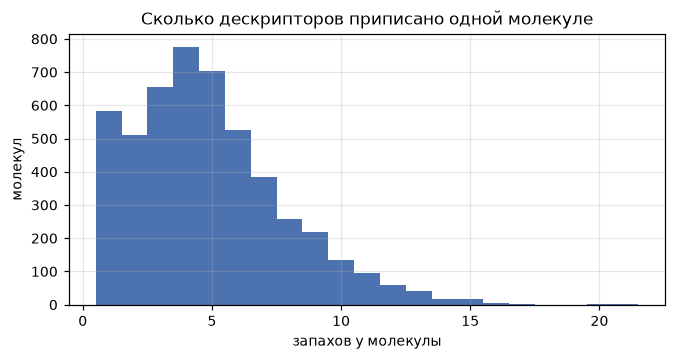

минимум 1, медиана 4, среднее 4.9, максимум 21
плотность матрицы меток: 3.5%


In [ ]:
per_molecule = Y.sum(axis=1)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(per_molecule, bins=np.arange(0.5, per_molecule.max() + 1.5), color="#4C72B0")
ax.set_xlabel("запахов у молекулы")
ax.set_ylabel("молекул")
ax.set_title("Сколько дескрипторов приписано одной молекуле")
plt.show()

print(
    f"минимум {per_molecule.min()}, медиана {int(np.median(per_molecule))}, "
    f"среднее {per_molecule.mean():.1f}, максимум {per_molecule.max()}"
)
print(f"плотность матрицы меток: {Y.mean() * 100:.1f}%")

Матрица заполнена единицами всего на **3.5%**. Поэтому модель, которая всегда отвечает «нет» на все 138 вопросов,
получит около 96.5% правильных ответов и не будет знать ни одного запаха.

## 3. Частоты дескрипторов и что они делают с измерением

Здесь главный вывод всего блокнота.

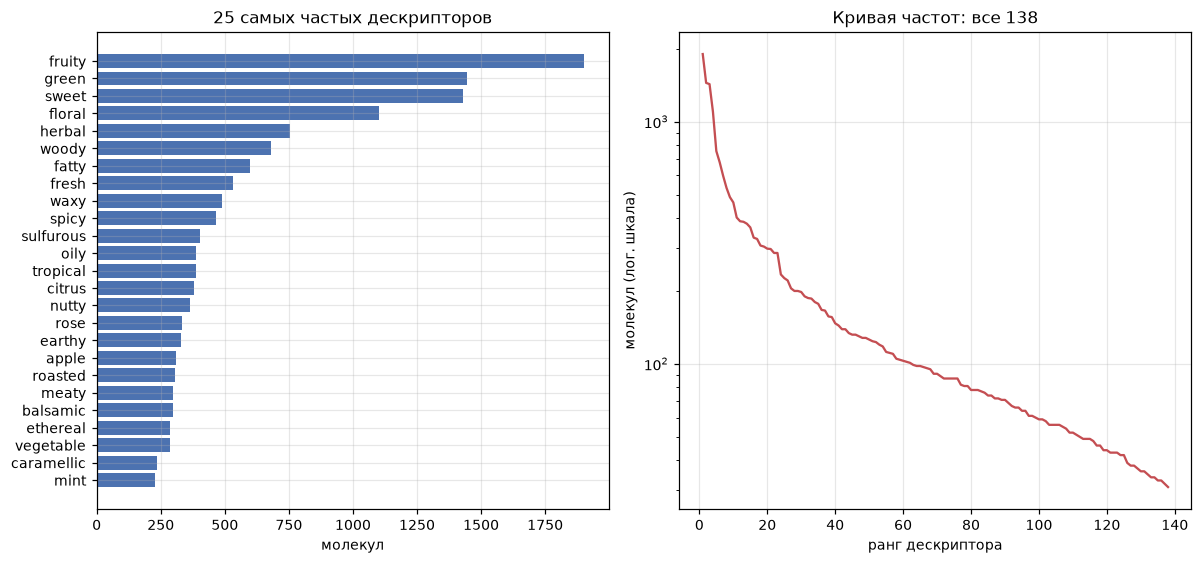

самый частый: fruity = 1902
самый редкий: chamomile = 31
отношение частот: 61 : 1


In [ ]:
freq = pd.Series(Y.sum(axis=0), index=labels).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))

top = freq.head(25)[::-1]
axes[0].barh(top.index, top.to_numpy(), color="#4C72B0")
axes[0].set_title("25 самых частых дескрипторов")
axes[0].set_xlabel("молекул")

axes[1].plot(range(1, len(freq) + 1), freq.to_numpy(), color="#C44E52")
axes[1].set_yscale("log")
axes[1].set_xlabel("ранг дескриптора")
axes[1].set_ylabel("молекул (лог. шкала)")
axes[1].set_title("Кривая частот: все 138")
plt.tight_layout()
plt.show()

print(f"самый частый: {freq.index[0]} = {freq.iloc[0]}")
print(f"самый редкий: {freq.index[-1]} = {freq.iloc[-1]}")
print(f"отношение частот: {freq.iloc[0] / freq.iloc[-1]:.0f} : 1")

In [ ]:
# Сколько положительных примеров редкий класс получит в тестовой части сплита 80/10/10
test_share = 0.10
expected_test = (freq * test_share).round().astype(int)

buckets = {
    "0-2 примера  (метрика не считается или бессмысленна)": int((expected_test <= 2).sum()),
    "3-5 примеров (метрика есть, но шумит сильнее эффекта)": int(expected_test.between(3, 5).sum()),
    "6-15 примеров": int(expected_test.between(6, 15).sum()),
    "16+ примеров": int((expected_test > 15).sum()),
}
for name, count in buckets.items():
    print(f"{count:>4} дескрипторов — {name}")

   0 дескрипторов — 0-2 примера  (метрика не считается или бессмысленна)
  31 дескрипторов — 3-5 примеров (метрика есть, но шумит сильнее эффекта)
  68 дескрипторов — 6-15 примеров
  39 дескрипторов — 16+ примеров


Вот это и есть настоящая проблема Фазы 1, и она не про обучение.

У самого редкого дескриптора 31 пример на весь датасет. В тестовой десятине их окажется
около трёх. Average Precision, посчитанная по трём положительным примерам, скачет на
десятые доли от перестановки одной молекулы в ранжировании. Модель при этом обучается
совершенно нормально — ломается **инструмент измерения**: он шумит сильнее, чем разница
между сравниваемыми моделями.

Отсюда два требования к шагам 1.3 и 1.4:

- сплит должен быть **стратифицированным по меткам**, иначе редкий класс может не попасть
  в тест вовсе и его AP окажется неопределена;
- результат должен сообщаться как **разброс по нескольким сидам**, а не одним числом,
  иначе «улучшение» будет неотличимо от удачного случайного разбиения.

## 4. Какие запахи ходят парами

Если дескрипторы независимы, предсказывать их можно по отдельности. Если между ними есть
структура, её можно использовать — и она же объясняет, почему модель путает одно с другим.

Мера — **lift**: во сколько раз пара встречается чаще, чем если бы метки были независимы.
Lift = 1 означает независимость, больше 1 — притяжение.

In [ ]:
n = len(df)
counts = Y.sum(axis=0)
co = Y.T.astype(int) @ Y.astype(int)  # сколько молекул имеет обе метки
expected = np.outer(counts, counts) / n  # ожидание при независимости

with np.errstate(divide="ignore", invalid="ignore"):
    lift = np.where(expected > 0, co / expected, 0.0)

iu = np.triu_indices(len(labels), k=1)
pairs = (
    pd.DataFrame(
        {
            "a": np.array(labels)[iu[0]],
            "b": np.array(labels)[iu[1]],
            "вместе": co[iu],
            "lift": lift[iu],
        }
    )
    .query("вместе >= 20")
    .sort_values("lift", ascending=False)
)
pairs.head(15).reset_index(drop=True)

,a,b,вместе,lift
0,lily,muguet,25,31.331740
1,almond,bitter,34,30.427802
2,cocoa,malty,21,26.872881
3,coconut,coumarinic,29,26.466484
4,almond,cherry,35,24.447014
5,fermented,malty,21,21.571429
6,garlic,onion,91,21.349011
7,alliaceous,garlic,63,20.762500
8,coconut,lactonic,25,20.432180
9,apricot,peach,30,20.174089


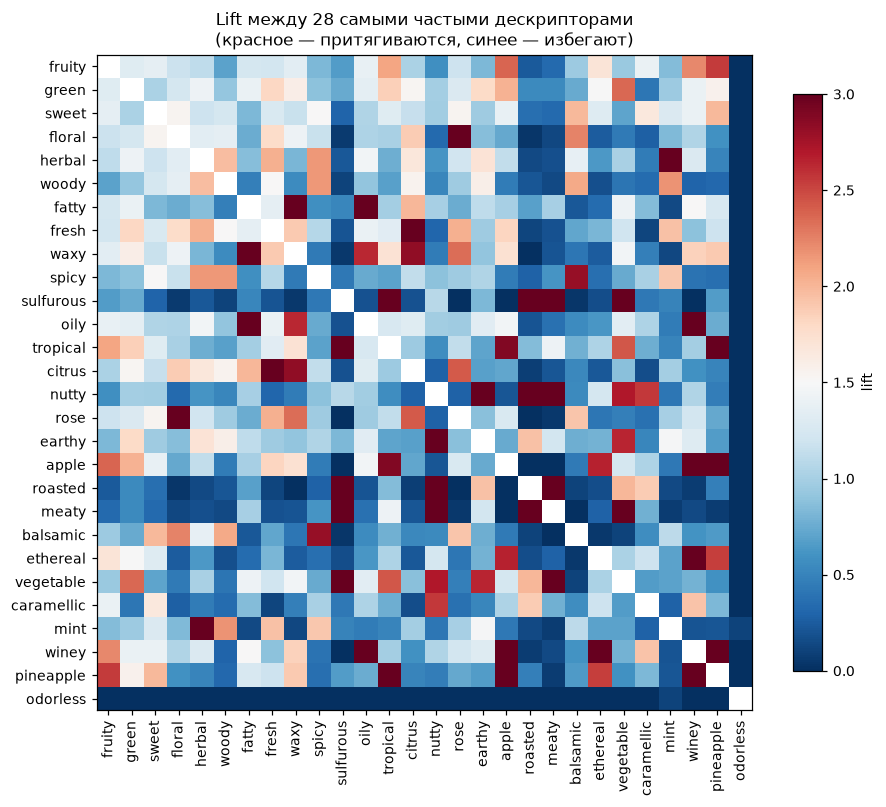

In [ ]:
top_labels = freq.head(28).index.tolist()
idx = [labels.index(name) for name in top_labels]
sub = lift[np.ix_(idx, idx)].copy()
np.fill_diagonal(sub, np.nan)

fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(sub, cmap="RdBu_r", vmin=0, vmax=3)
ax.set_xticks(range(len(top_labels)), top_labels, rotation=90)
ax.set_yticks(range(len(top_labels)), top_labels)
ax.set_title(
    "Lift между 28 самыми частыми дескрипторами\n(красное — притягиваются, синее — избегают)"
)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="lift")
plt.tight_layout()
plt.show()

Пары с высоким lift — не случайность, а химия и восприятие: фруктовые эфиры, серные
соединения, лактоны. Синие зоны не менее интересны: дескрипторы, которые почти никогда
не встречаются вместе, задают оси ольфакторного пространства — то самое, что в Фазе 3
станет картой запахов.

## 5. Сами молекулы

До сих пор мы смотрели только на метки. Теперь на структуры — через RDKit, библиотеку
для работы с молекулами, которая станет основой признаков в шаге 1.2.

Первый вопрос — сугубо практический: **все ли SMILES вообще читаются**. Если часть строк
не парсится, они выпадут из обучения, и знать об этом надо сейчас, а не в середине Фазы 2.

In [ ]:
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, Draw

RDLogger.DisableLog("rdApp.*")  # RDKit пишет предупреждения в stderr, они здесь только мешают

mols = [Chem.MolFromSmiles(s) for s in df[SMILES_COLUMN]]
bad = [s for s, m in zip(df[SMILES_COLUMN], mols, strict=True) if m is None]

print(f"распарсилось: {sum(m is not None for m in mols)} из {len(mols)}")
print(f"не распарсилось: {len(bad)}")
if bad:
    print("примеры:", bad[:5])

распарсилось: 4983 из 4983
не распарсилось: 0


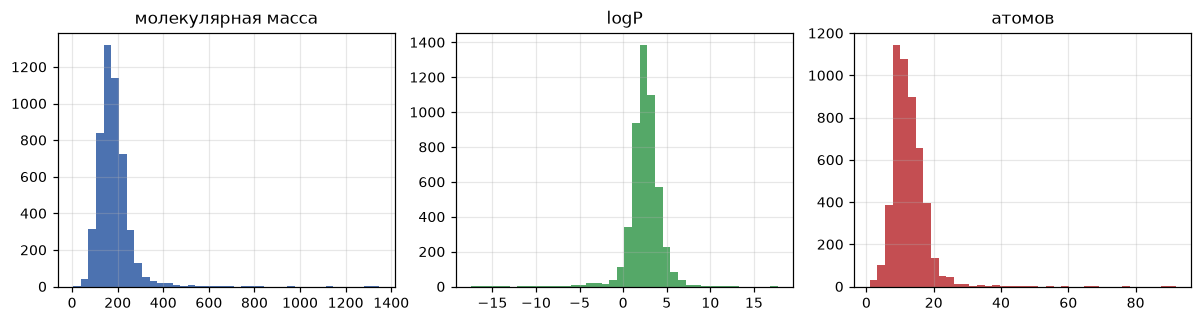

,атомов,молекулярная масса,logP,колец
count,4983.0,4983.0,4983.0,4983.0
mean,12.6,180.5,2.4,0.8
std,5.1,70.8,2.0,1.0
min,1.0,4.0,-17.4,0.0
25%,10.0,140.2,1.7,0.0
50%,12.0,170.3,2.5,1.0
75%,15.0,207.2,3.4,1.0
max,92.0,1347.4,17.7,30.0


In [ ]:
props = pd.DataFrame(
    {
        "атомов": [m.GetNumHeavyAtoms() for m in mols],
        "молекулярная масса": [Descriptors.MolWt(m) for m in mols],
        "logP": [Descriptors.MolLogP(m) for m in mols],
        "колец": [Chem.rdMolDescriptors.CalcNumRings(m) for m in mols],
    }
)

fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, column, color in zip(
    axes, ["молекулярная масса", "logP", "атомов"], ["#4C72B0", "#55A868", "#C44E52"], strict=True
):
    ax.hist(props[column], bins=40, color=color)
    ax.set_title(column)
plt.tight_layout()
plt.show()

props.describe().round(1)

Молекулы маленькие: медианная масса около 150-170, редко больше 300. Это принципиально
для проекта — такие графы обучаются на T4 за минуты, а не за сутки, и вся Фаза 2
укладывается в бесплатные ресурсы.

`logP` — мера жирорастворимости. В Фазе 3 она понадобится напрямую: летучесть определяет,
станет молекула верхней нотой или базовой, и именно из неё вырастает кривая испарения.

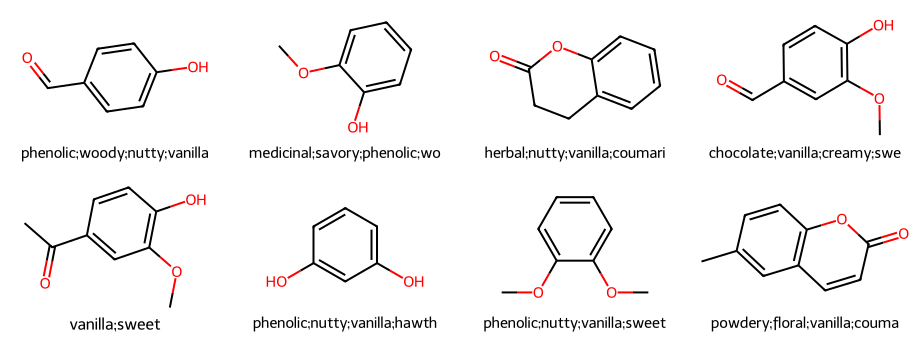

In [ ]:
def draw(descriptor: str, k: int = 8):
    subset = df[df[descriptor] == 1].head(k)
    picked = [Chem.MolFromSmiles(s) for s in subset[SMILES_COLUMN]]
    captions = [d[:28] for d in subset[DESCRIPTORS_COLUMN]]
    return Draw.MolsToGridImage(picked, molsPerRow=4, subImgSize=(230, 170), legends=captions)


draw("vanilla")

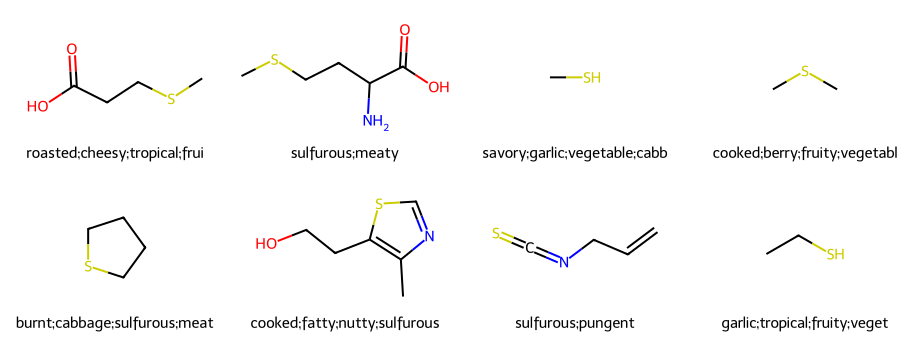

In [ ]:
draw("sulfurous")

Разница видна глазами: у «ванильных» молекул — ароматические кольца с кислородными
заместителями, у «серных» — атомы серы. Это ровно тот сигнал, который должна поймать
модель, и заодно первая проверка на здравый смысл: если бейзлайн не отличит эти два
класса, дело не в данных.

## 6. Странности разметки

Последний обязательный шаг разведки — искать не закономерности, а аномалии.

In [ ]:
is_odorless = df["odorless"].to_numpy() == 1
also_smells = int((Y[is_odorless].sum(axis=1) > 1).sum())

print(f"молекул с меткой odorless: {is_odorless.sum()}")
print(f"из них имеют ещё какие-то запахи: {also_smells}")
print()

crowded = df.loc[per_molecule >= 15, [SMILES_COLUMN, DESCRIPTORS_COLUMN]]
print(f"молекул с 15+ дескрипторами: {len(crowded)}")
crowded.head(5)

молекул с меткой odorless: 200
из них имеют ещё какие-то запахи: 1

молекул с 15+ дескрипторами: 25


,nonStereoSMILES,descriptors
272,CC(C)=CCCC(C)CCO,fresh;powdery;floral;rose;fruity;leafy;green;f...
386,CC(=O)c1ccccc1O,cherry;phenolic;herbal;tropical;bitter;coumari...
403,CCCCOC(=O)C(C)O,lactonic;earthy;fermented;cheesy;fruity;vanill...
461,CCCC=CC=O,fresh;grassy;bitter;cheesy;fruity;vegetable;sw...
524,CCCCCC(O)CC,herbal;woody;waxy;nutty;dairy;green;mushroom;c...


In [ ]:
lonely = df.loc[per_molecule == 1]
print(f"молекул ровно с одним дескриптором: {len(lonely)} ({len(lonely) / len(df) * 100:.1f}%)")
print("\nчаще всего единственная метка — это:")
print(lonely[DESCRIPTORS_COLUMN].value_counts().head(10).to_string())

молекул ровно с одним дескриптором: 582 (11.7%)

чаще всего единственная метка — это:
descriptors
odorless      199
fruity         42
waxy           24
fatty          24
sulfurous      20
woody          18
sweet          16
caramellic     13
green          13
spicy          12


### Противоречие в разметке

Из 200 молекул с меткой `odorless` ровно одна имеет ещё какие-то запахи. «Не пахнет»
и «пахнет чем-то» — взаимоисключающие утверждения, так что это либо ошибка разметки,
либо результат склейки двух источников с разными мнениями.

In [ ]:
contradiction = df[(df["odorless"] == 1) & (per_molecule > 1)]
contradiction[[SMILES_COLUMN, DESCRIPTORS_COLUMN]]

,nonStereoSMILES,descriptors
3664,CC1CCC(C(C)C)C(OC(=O)C(C)O)C1,mint;cooling;odorless


И противоречие оказывается мнимым. `CC1CCC(C(C)C)C(OC(=O)C(C)O)C1` — это ментиллактат,
сложный эфир ментола и молочной кислоты. Он действительно почти не пахнет, но даёт
отчётливое ощущение холода.

Холод — **не запах**. Это тригеминальное ощущение, рецептор TRPM8, отдельный нерв,
не имеющий отношения к обонятельному эпителию. То же касается `pungent`, `cooling`,
`sharp`.

Вывод, который стоит держать в голове всю Фазу 1: словарь из 138 «ольфакторных
дескрипторов» на самом деле смешивает два разных канала восприятия. Модель, обученная
на структуре, будет предсказывать их одинаково, хотя физика за ними разная. Это не
ошибка данных, но это ограничение постановки задачи, и о нём честнее сказать в model card,
чем умолчать.

### Молекулярные выбросы

Медиана — 12 тяжёлых атомов, а максимум 92, при 30 циклах и массе 1347. Для набора
летучих пахучих веществ это аномалия: молекула такого размера физически не долетит до
обонятельного рецептора.

In [ ]:
outliers = props.assign(
    smiles=df[SMILES_COLUMN].to_numpy(), descriptors=df[DESCRIPTORS_COLUMN].to_numpy()
)
big = outliers.nlargest(6, "молекулярная масса")
big[["молекулярная масса", "атомов", "колец", "descriptors", "smiles"]]

,молекулярная масса,атомов,колец,descriptors,smiles
4855,1347.385,92,8,odorless,CC1=C2N=C(C=C3N=C(C(C)=C4[N-]C(C(CC(N)=O)C4(C)...
3785,1297.128,88,30,odorless,OCC1OC2OC3C(CO)OC(OC4C(CO)OC(OC5C(CO)OC(OC6C(C...
3588,1134.987,77,21,odorless,OCC1OC2OC3C(CO)OC(OC4C(CO)OC(OC5C(CO)OC(OC6C(C...
3606,972.846,66,22,odorless,OCC1OC2OC3C(CO)OC(OC4C(CO)OC(OC5C(CO)OC(OC6C(C...
4648,965.580,68,0,waxy,CC(C)CCCCCCCCCCCCCCC(=O)OCC(O)COCC(COC(=O)CCCC...
3542,822.942,58,7,spicy,CC1(C(=O)O)CCC2(C)CCC3(C)C(=CC(=O)C4C5(C)CCC(O...


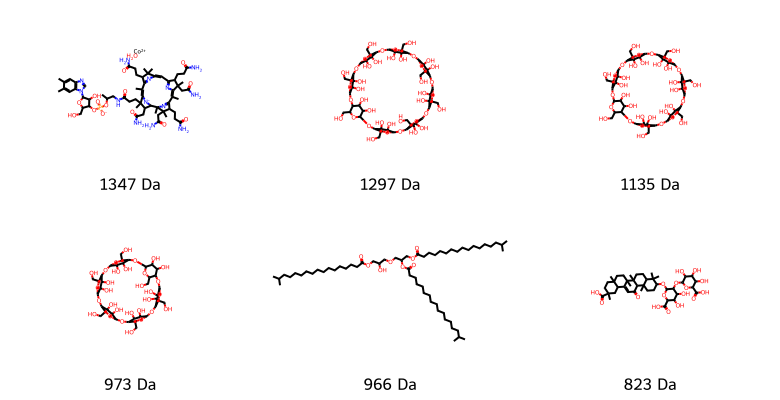

In [ ]:
heavy = [Chem.MolFromSmiles(s) for s in big["smiles"]]
Draw.MolsToGridImage(
    heavy,
    molsPerRow=3,
    subImgSize=(260, 200),
    legends=[f"{m:.0f} Da" for m in big["молекулярная масса"]],
)

Обрати внимание на колонку с дескрипторами: **все самые тяжёлые молекулы помечены
`odorless`**. Это не совпадение, а физика. Чтобы пахнуть, вещество должно испариться и
долететь до обонятельного эпителия; молекула в 1300 дальтон не испаряется при комнатной
температуре ни при каких условиях.

По структурам видно, что это: повторяющийся мотив `OCC1OC2OC3C(CO)OC(...)` — циклодекстрины,
циклические олигомеры глюкозы. В парфюмерии их используют ровно наоборот — как **поглотители**
запаха и капсулы для отдушек. Самая тяжёлая молекула с мотивом `[N-]` и амидными хвостами
похожа на кобаламин.

Практический вывод: данные содержат сигнал «слишком большая, чтобы пахнуть», и модель
почти наверняка его выучит. Это хорошо, но при анализе в шаге 1.6 надо будет проверить,
не свелось ли предсказание `odorless` к простому «посмотри на молекулярную массу» —
иначе мы получим правильный ответ по неправильной причине.

Удалять выбросы сейчас нельзя: решения по данным принимаются с обоснованием и
записываются в журнал, а не по ходу разведки.

## Выводы для Фазы 1

**Что мы теперь знаем.**

1. Задача мультилейбловая и разреженная: 3.5% заполнения, медиана 4 метки на молекулу.
   Accuracy бессмысленна арифметически, а не идеологически.
2. Дисбаланс 61:1 — заметный, но не катастрофический: у самого редкого класса 31 пример.
   Проблема не в обучении, а в измерении на редких классах.
3. Дескрипторы не независимы; есть устойчивые пары с высоким lift и есть взаимно
   исключающие зоны.
4. Все SMILES читаются RDKit, молекулы маленькие — вычислительных препятствий нет.
5. Разметка чистая. Единственное найденное «противоречие» с `odorless` оказалось
   ментиллактатом и вскрыло более интересное: словарь смешивает обоняние и
   тригеминальные ощущения (`cooling`, `pungent`, `sharp`). Это ограничение
   постановки задачи, его место — в model card.
6. Самые тяжёлые молекулы (циклодекстрины, до 1347 Da) все помечены `odorless` —
   физика испарения проступает прямо в данных. В шаге 1.6 надо проверить, не свёлся
   ли предсказатель `odorless` к молекулярной массе.

**Что из этого следует для следующих шагов.**

- **1.2 признаки:** RDKit-дескрипторы и Morgan fingerprints; молекулы маленькие,
  считается быстро.
- **1.3 сплит:** стратификация по меткам обязательна; проверять,
  что каждый дескриптор представлен во всех частях.
- **1.4 метрики:** per-label AP и AUC, макро- и микро-усреднение;
  обязательно разброс по нескольким сидам, а не одно число.
- **1.6 анализ:** график «качество против частоты дескриптора» — по кривой из раздела 3
  уже видно, где ожидать провал.